In [2]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

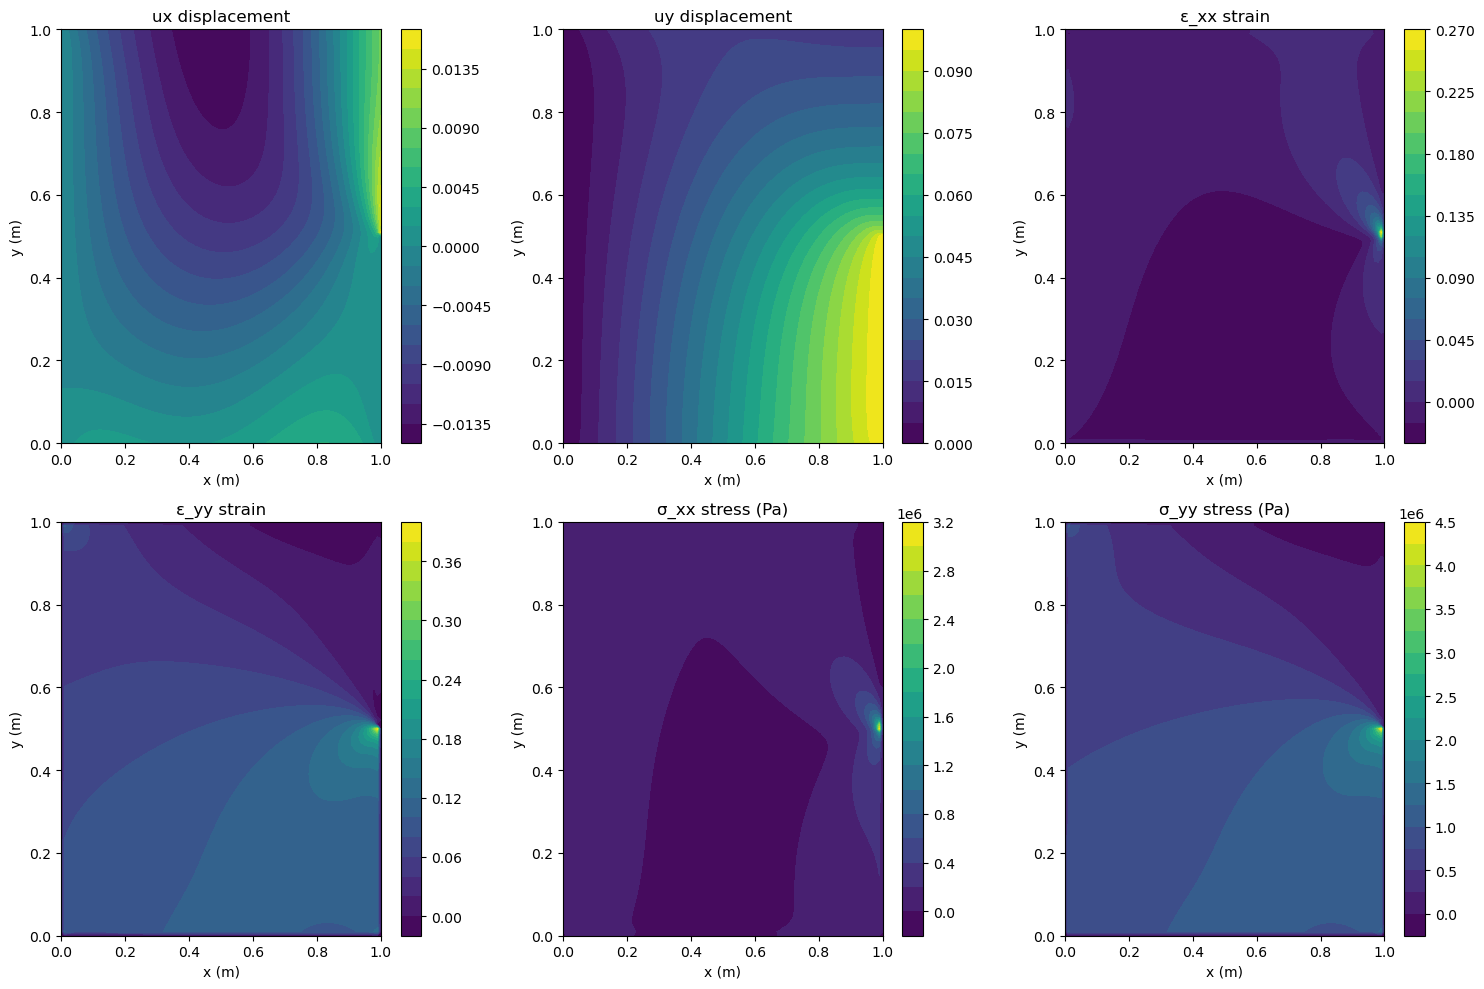

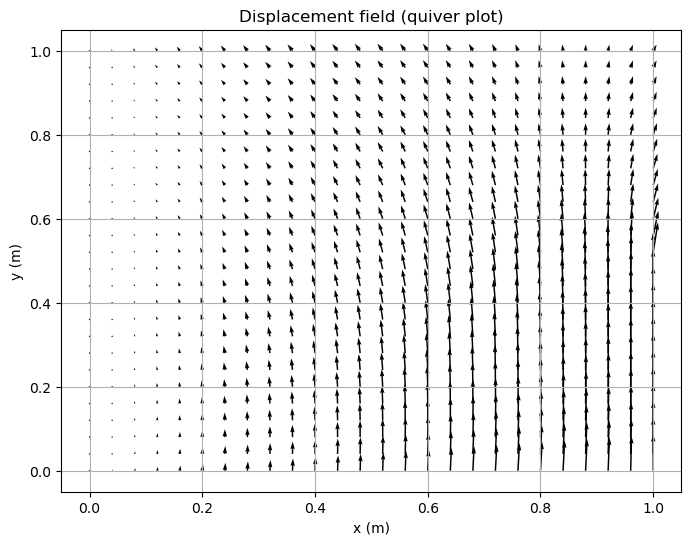

In [3]:
# Parameters
E = 10e6
nu = 0.2
L = 1.0
n = 101  # Number of grid points
h = L / (n - 1)
i_half = int(0.5 * (n - 1))  # i <= i_half for top-left Dirichlet (i=0 to 25 for n=51)

# Material constants for plane stress
C11 = E / (1 - nu**2)
C12 = nu * E / (1 - nu**2)
C66 = E / (2 * (1 + nu))
alpha = C12 + C66

# Total unknowns
N = 2 * n * n

# Function to get flat index
def flat_idx(i, j, k):
    return (j * n + i) * 2 + k

# Initialize sparse matrix and RHS
A = lil_matrix((N, N))
b = np.zeros(N)

# Loop over all grid points
for j in range(n):
    for i in range(n):
        base = (j * n + i) * 2
        row_x = base
        row_y = base + 1
        ux_col = base
        uy_col = base + 1

        # Check if Dirichlet
        is_dir = False
        val_ux = 0.0
        val_uy = 0.0
        if j == 0:
            is_dir = True
            val_ux = 0.0
            val_uy = 0.0
        elif j == n - 1 and i <= i_half:
            is_dir = True
            val_ux = 0.0
            val_uy = 0.1

        if is_dir:
            # Dirichlet equations
            A[row_x, ux_col] = 1.0
            b[row_x] = val_ux
            A[row_y, uy_col] = 1.0
            b[row_y] = val_uy
        else:
            # Non-Dirichlet: determine type of equations
            if 1 <= i <= n-2 and 1 <= j <= n-2:
                # Interior: Navier equations
                coeff_h2 = 1.0 / h**2
                coeff_m = alpha / (4.0 * h**2)

                # ux equation (row_x)
                A[row_x, flat_idx(i+1, j, 0)] = C11 * coeff_h2
                A[row_x, flat_idx(i-1, j, 0)] = C11 * coeff_h2
                A[row_x, flat_idx(i, j, 0)] += -2 * C11 * coeff_h2
                A[row_x, flat_idx(i, j+1, 0)] = C66 * coeff_h2
                A[row_x, flat_idx(i, j-1, 0)] = C66 * coeff_h2
                A[row_x, flat_idx(i, j, 0)] += -2 * C66 * coeff_h2

                A[row_x, flat_idx(i+1, j+1, 1)] = coeff_m
                A[row_x, flat_idx(i+1, j-1, 1)] = -coeff_m
                A[row_x, flat_idx(i-1, j+1, 1)] = -coeff_m
                A[row_x, flat_idx(i-1, j-1, 1)] = coeff_m

                # uy equation (row_y)
                A[row_y, flat_idx(i, j+1, 1)] = C11 * coeff_h2
                A[row_y, flat_idx(i, j-1, 1)] = C11 * coeff_h2
                A[row_y, flat_idx(i, j, 1)] += -2 * C11 * coeff_h2
                A[row_y, flat_idx(i+1, j, 1)] = C66 * coeff_h2
                A[row_y, flat_idx(i-1, j, 1)] = C66 * coeff_h2
                A[row_y, flat_idx(i, j, 1)] += -2 * C66 * coeff_h2

                A[row_y, flat_idx(i+1, j+1, 0)] = coeff_m
                A[row_y, flat_idx(i+1, j-1, 0)] = -coeff_m
                A[row_y, flat_idx(i-1, j+1, 0)] = -coeff_m
                A[row_y, flat_idx(i-1, j-1, 0)] = coeff_m

            elif j == n - 1 and i > i_half:
                # Top traction-free boundary
                if i == n - 1:
                    # Top-right corner: one-sided approximations
                    # σyy = 0 (row_y): multiplied by h
                    A[row_y, flat_idx(i, j, 1)] = C11
                    A[row_y, flat_idx(i, j-1, 1)] = -C11
                    A[row_y, flat_idx(i, j, 0)] = C12
                    A[row_y, flat_idx(i-1, j, 0)] = -C12

                    # τxy = 0 (row_x): multiplied by h
                    A[row_x, flat_idx(i, j, 0)] = C66
                    A[row_x, flat_idx(i, j-1, 0)] = -C66
                    A[row_x, flat_idx(i, j, 1)] = C66
                    A[row_x, flat_idx(i-1, j, 1)] = -C66
                else:
                    # Top non-corner: central in x, backward in y (multiplied by 2h)
                    # σyy = 0 (row_y)
                    A[row_y, flat_idx(i, j, 1)] = 2 * C11
                    A[row_y, flat_idx(i, j-1, 1)] = -2 * C11
                    A[row_y, flat_idx(i+1, j, 0)] = C12
                    A[row_y, flat_idx(i-1, j, 0)] = -C12

                    # τxy = 0 (row_x)
                    A[row_x, flat_idx(i, j, 0)] = 2 * C66
                    A[row_x, flat_idx(i, j-1, 0)] = -2 * C66
                    A[row_x, flat_idx(i+1, j, 1)] = C66
                    A[row_x, flat_idx(i-1, j, 1)] = -C66

            elif (i == 0 or i == n - 1) and 1 <= j <= n - 2:
                # Side traction-free boundaries (multiplied by 2h)
                if i == 0:
                    # Left: σxx = 0 (row_x), τxy = 0 (row_y)
                    A[row_x, flat_idx(1, j, 0)] = 2 * C11
                    A[row_x, flat_idx(0, j, 0)] = -2 * C11
                    A[row_x, flat_idx(0, j+1, 1)] = C12
                    A[row_x, flat_idx(0, j-1, 1)] = -C12

                    A[row_y, flat_idx(0, j+1, 0)] = C66
                    A[row_y, flat_idx(0, j-1, 0)] = -C66
                    A[row_y, flat_idx(1, j, 1)] = 2 * C66
                    A[row_y, flat_idx(0, j, 1)] = -2 * C66
                else:
                    # Right: σxx = 0 (row_x), τxy = 0 (row_y)
                    A[row_x, flat_idx(n-1, j, 0)] = 2 * C11
                    A[row_x, flat_idx(n-2, j, 0)] = -2 * C11
                    A[row_x, flat_idx(n-1, j+1, 1)] = C12
                    A[row_x, flat_idx(n-1, j-1, 1)] = -C12

                    A[row_y, flat_idx(n-1, j+1, 0)] = C66
                    A[row_y, flat_idx(n-1, j-1, 0)] = -C66
                    A[row_y, flat_idx(n-1, j, 1)] = 2 * C66
                    A[row_y, flat_idx(n-2, j, 1)] = -2 * C66
            else:
                raise ValueError(f"Unhandled point at i={i}, j={j}")

# Convert to CSR and solve
A = A.tocsr()
u_flat = spsolve(A, b)

# Extract ux and uy (ux[i,j] at x_i, y_j)
ux = np.zeros((n, n))
uy = np.zeros((n, n))
for j in range(n):
    for i in range(n):
        base = (j * n + i) * 2
        ux[i, j] = u_flat[base]
        uy[i, j] = u_flat[base + 1]

# Compute strains and stresses at interior points (central differences)
exx = np.zeros((n, n))
eyy = np.zeros((n, n))
exy = np.zeros((n, n))
sxx = np.zeros((n, n))
syy = np.zeros((n, n))
sxy = np.zeros((n, n))

for i in range(1, n-1):
    for j in range(1, n-1):
        exx[i, j] = (ux[i+1, j] - ux[i-1, j]) / (2 * h)
        eyy[i, j] = (uy[i, j+1] - uy[i, j-1]) / (2 * h)
        dux_dy = (ux[i, j+1] - ux[i, j-1]) / (2 * h)
        duy_dx = (uy[i+1, j] - uy[i-1, j]) / (2 * h)
        exy[i, j] = 0.5 * (dux_dy + duy_dx)

        sxx[i, j] = C11 * exx[i, j] + C12 * eyy[i, j]
        syy[i, j] = C12 * exx[i, j] + C11 * eyy[i, j]
        sxy[i, j] = 2 * C66 * exy[i, j]

# Boundary points remain zero (for plotting purposes; in reality, extrapolate or use one-sided)

# Grid for plotting
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)

# Plots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# ux
im1 = axs[0, 0].contourf(X, Y, ux, levels=20)
axs[0, 0].set_title('ux displacement')
plt.colorbar(im1, ax=axs[0, 0])

# uy
im2 = axs[0, 1].contourf(X, Y, uy, levels=20)
axs[0, 1].set_title('uy displacement')
plt.colorbar(im2, ax=axs[0, 1])

# εxx
im3 = axs[0, 2].contourf(X, Y, exx, levels=20)
axs[0, 2].set_title('ε_xx strain')
plt.colorbar(im3, ax=axs[0, 2])

# εyy
im4 = axs[1, 0].contourf(X, Y, eyy, levels=20)
axs[1, 0].set_title('ε_yy strain')
plt.colorbar(im4, ax=axs[1, 0])

# σxx
im5 = axs[1, 1].contourf(X, Y, sxx, levels=20)
axs[1, 1].set_title('σ_xx stress (Pa)')
plt.colorbar(im5, ax=axs[1, 1])

# σyy
im6 = axs[1, 2].contourf(X, Y, syy, levels=20)
axs[1, 2].set_title('σ_yy stress (Pa)')
plt.colorbar(im6, ax=axs[1, 2])

for ax in axs.flat:
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

plt.tight_layout()
plt.show()

# Additional plot: displacement quiver (subsampled for clarity)
plt.figure(figsize=(8, 6))
step = 4  # Subsample
plt.quiver(X[::step, ::step], Y[::step, ::step], ux[::step, ::step], uy[::step, ::step])
plt.title('Displacement field (quiver plot)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(True)
plt.show()

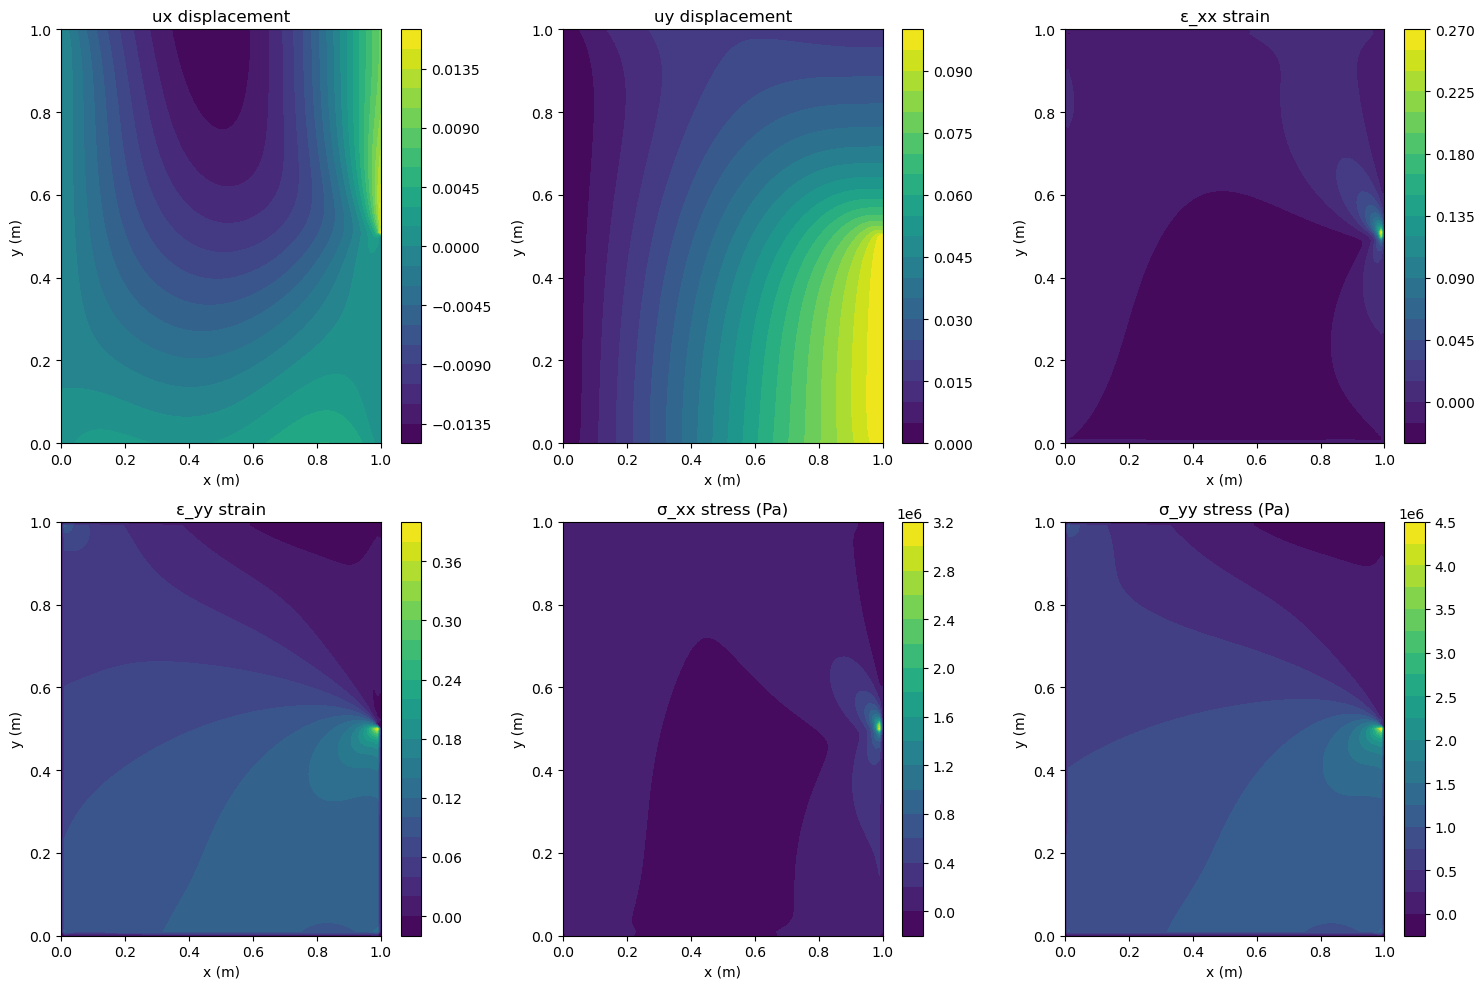

In [4]:
# 上面代码的xy弄反了，重新绘制
# Plots with corrected orientation
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# ux
im1 = axs[0, 0].contourf(Y, X, ux.T, levels=20)
axs[0, 0].set_title('ux displacement')
plt.colorbar(im1, ax=axs[0, 0])
# uy
im2 = axs[0, 1].contourf(Y, X, uy.T, levels=20)
axs[0, 1].set_title('uy displacement')
plt.colorbar(im2, ax=axs[0, 1])
# εxx
im3 = axs[0, 2].contourf(Y, X, exx.T, levels=20)
axs[0, 2].set_title('ε_xx strain')
plt.colorbar(im3, ax=axs[0, 2])
# εyy
im4 = axs[1, 0].contourf(Y, X, eyy.T, levels=20)
axs[1, 0].set_title('ε_yy strain')
plt.colorbar(im4, ax=axs[1, 0])
# σxx
im5 = axs[1, 1].contourf(Y, X, sxx.T, levels=20)
axs[1, 1].set_title('σ_xx stress (Pa)')
plt.colorbar(im5, ax=axs[1, 1])
# σyy
im6 = axs[1, 2].contourf(Y, X, syy.T, levels=20)
axs[1, 2].set_title('σ_yy stress (Pa)')
plt.colorbar(im6, ax=axs[1, 2])
for ax in axs.flat:
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
plt.tight_layout()
plt.show()

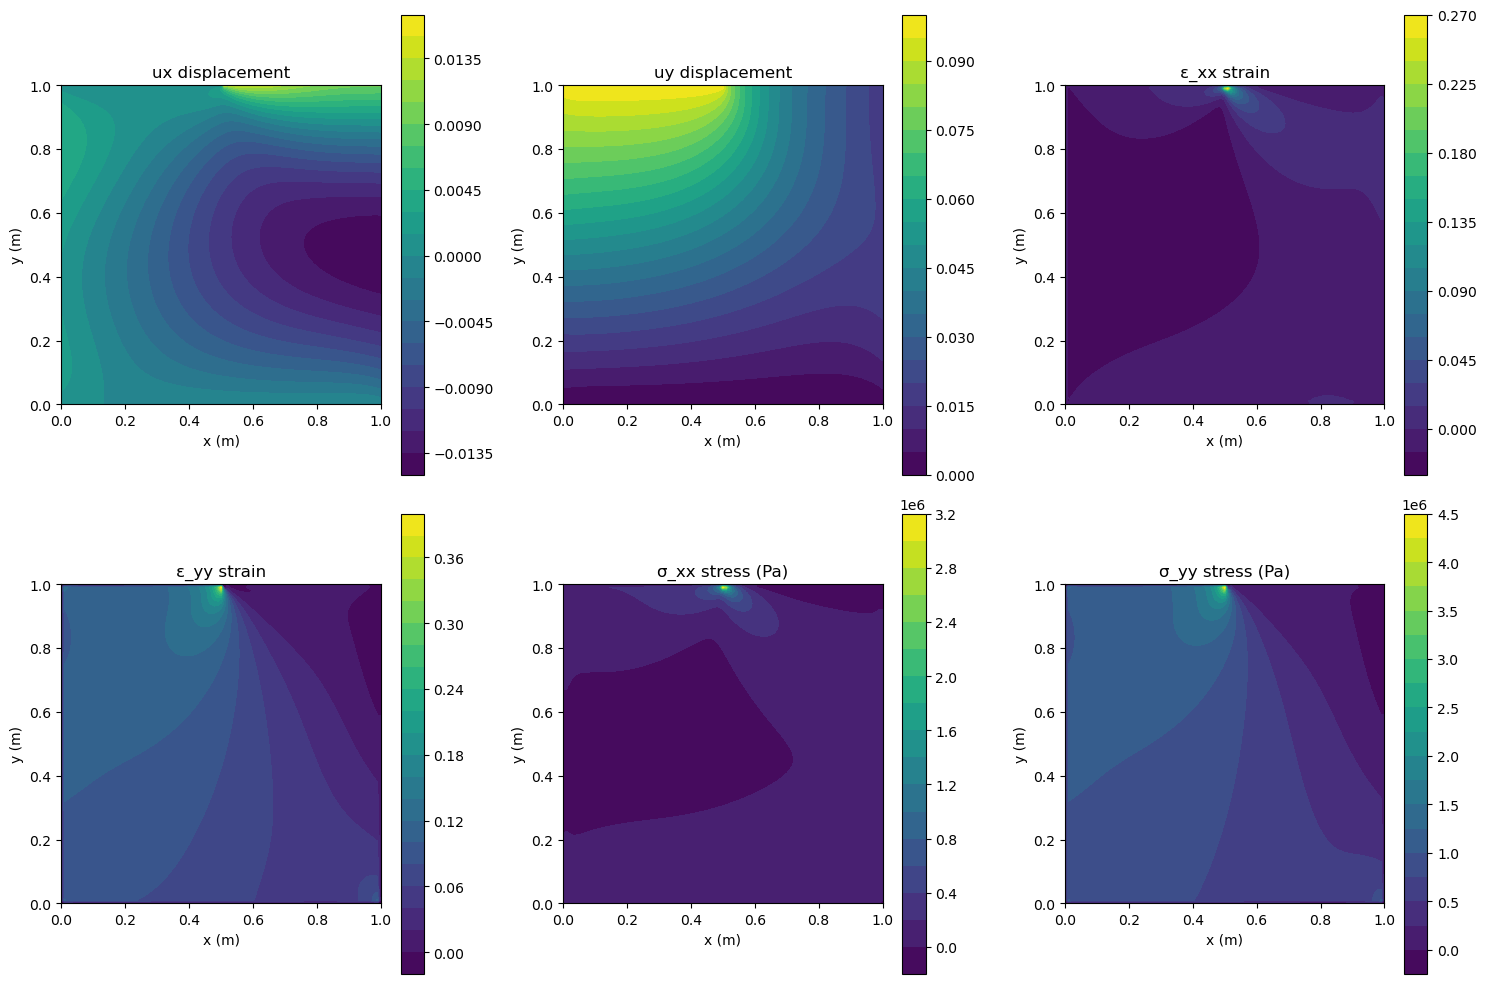

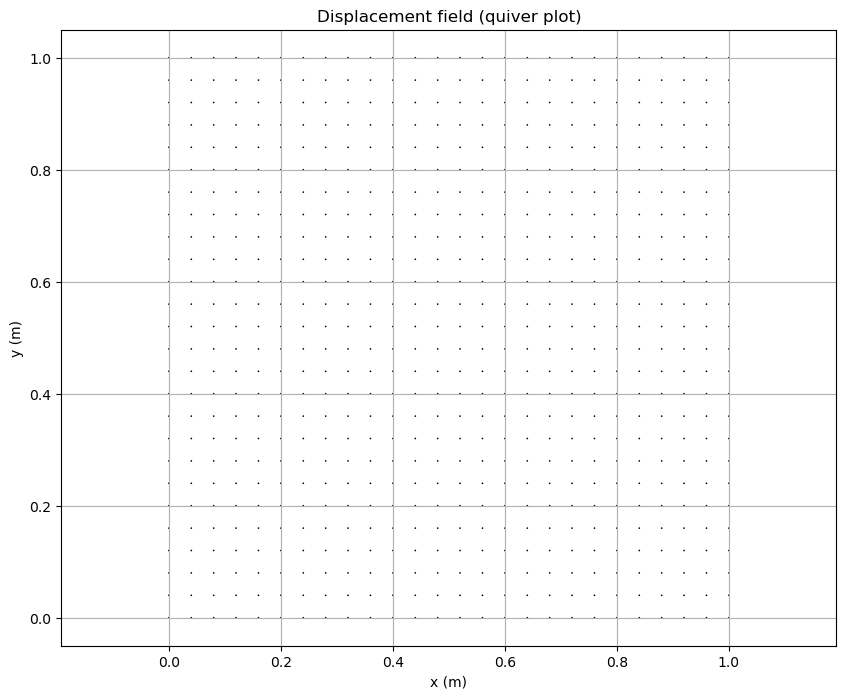

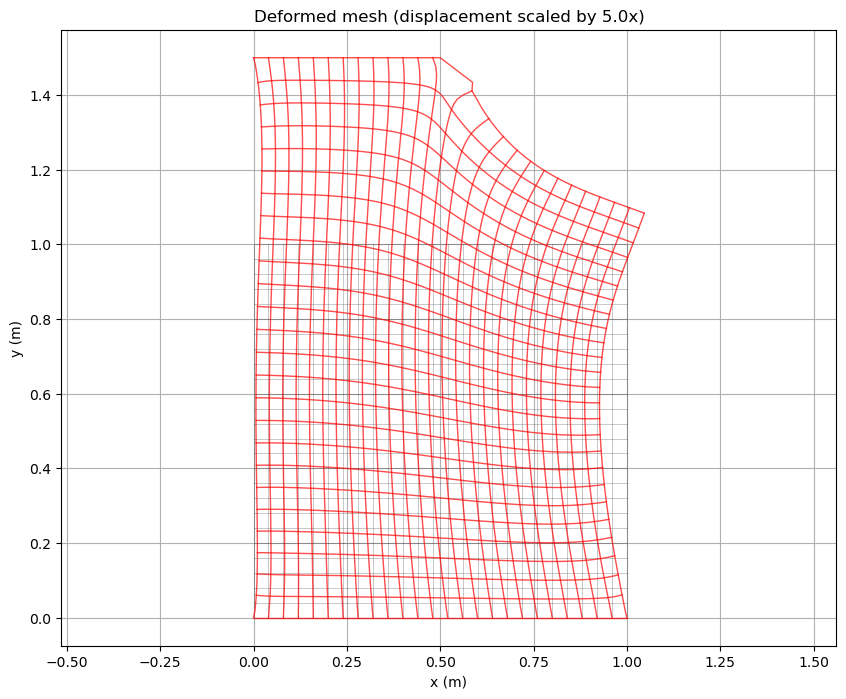

In [5]:
# 绘图部分 - 修正索引问题
# Grid for plotting - 使用indexing='ij'确保正确的索引对应
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y, indexing='ij')  # 重要修正：添加indexing='ij'

# Plots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# 注意：由于X,Y是(i,j)索引，而contourf期望网格是(y,x)顺序，我们需要使用X.T, Y.T或转置数据
# 方法1：转置数据
# ux
im1 = axs[0, 0].contourf(X, Y, ux, levels=20)
axs[0, 0].set_title('ux displacement')
axs[0, 0].set_aspect('equal')
plt.colorbar(im1, ax=axs[0, 0])

# uy
im2 = axs[0, 1].contourf(X, Y, uy, levels=20)
axs[0, 1].set_title('uy displacement')
axs[0, 1].set_aspect('equal')
plt.colorbar(im2, ax=axs[0, 1])

# εxx
im3 = axs[0, 2].contourf(X, Y, exx, levels=20)
axs[0, 2].set_title('ε_xx strain')
axs[0, 2].set_aspect('equal')
plt.colorbar(im3, ax=axs[0, 2])

# εyy
im4 = axs[1, 0].contourf(X, Y, eyy, levels=20)
axs[1, 0].set_title('ε_yy strain')
axs[1, 0].set_aspect('equal')
plt.colorbar(im4, ax=axs[1, 0])

# σxx
im5 = axs[1, 1].contourf(X, Y, sxx, levels=20)
axs[1, 1].set_title('σ_xx stress (Pa)')
axs[1, 1].set_aspect('equal')
plt.colorbar(im5, ax=axs[1, 1])

# σyy
im6 = axs[1, 2].contourf(X, Y, syy, levels=20)
axs[1, 2].set_title('σ_yy stress (Pa)')
axs[1, 2].set_aspect('equal')
plt.colorbar(im6, ax=axs[1, 2])

for ax in axs.flat:
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

plt.tight_layout()
plt.show()

# 添加额外的可视化：位移矢量图（使用原始索引）
plt.figure(figsize=(10, 8))
# 使用X, Y而不是X.T, Y.T，因为meshgrid用了indexing='ij'
step = 4  # Subsample
plt.quiver(X[::step, ::step], Y[::step, ::step], 
           ux[::step, ::step], uy[::step, ::step],
           scale=50, scale_units='inches')
plt.title('Displacement field (quiver plot)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.grid(True)
plt.axis('equal')
plt.show()

# 添加变形前后的对比图
plt.figure(figsize=(10, 8))
scale_factor = 5.0  # 位移放大因子，便于观察
X_deformed = X + ux * scale_factor
Y_deformed = Y + uy * scale_factor

# 绘制原始网格
for j in range(0, n, 4):
    plt.plot(X[:, j], Y[:, j], 'k-', alpha=0.3, linewidth=0.5)
for i in range(0, n, 4):
    plt.plot(X[i, :], Y[i, :], 'k-', alpha=0.3, linewidth=0.5)

# 绘制变形后的网格
for j in range(0, n, 4):
    plt.plot(X_deformed[:, j], Y_deformed[:, j], 'r-', alpha=0.7, linewidth=1)
for i in range(0, n, 4):
    plt.plot(X_deformed[i, :], Y_deformed[i, :], 'r-', alpha=0.7, linewidth=1)

plt.title(f'Deformed mesh (displacement scaled by {scale_factor}x)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True)
plt.show()

In [6]:
# ... 上面是原有的代码 ...

# 将所有数据保存到一个CSV文件
print("\n保存数据到CSV文件...")

# 准备数据数组
# 我们将保存：x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy
data = np.zeros((n * n, 10))

# 填充数据
index = 0
for j in range(n):
    for i in range(n):
        data[index, 0] = i * h  # x
        data[index, 1] = j * h  # y
        data[index, 2] = ux[i, j]  # ux
        data[index, 3] = uy[i, j]  # uy
        data[index, 4] = exx[i, j]  # exx
        data[index, 5] = eyy[i, j]  # eyy
        data[index, 6] = exy[i, j]  # exy (张量剪应变)
        data[index, 7] = sxx[i, j]  # sxx
        data[index, 8] = syy[i, j]  # syy
        data[index, 9] = sxy[i, j]  # sxy
        index += 1

# 保存到CSV文件
filename = "results_p1-1_Grok.csv"
np.savetxt(
    filename, 
    data, 
    delimiter=',',
    fmt='%.6e',
    header='x,y,ux,uy,exx,eyy,exy,sxx,syy,sxy',
    comments=''
)

print(f"数据已保存到: {filename}")
print(f"数据形状: {data.shape}")
print(f"列: x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy")
print("保存完成!")


保存数据到CSV文件...
数据已保存到: results_p1-1_Grok.csv
数据形状: (10201, 10)
列: x, y, ux, uy, exx, eyy, exy, sxx, syy, sxy
保存完成!
